<a href="https://colab.research.google.com/github/amyahespanol/Amyah-Espanol-Statistical-Theory-APM1111/blob/main/Stats_FA12_Espanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 17.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 15.7 MB/s eta 0:00:00


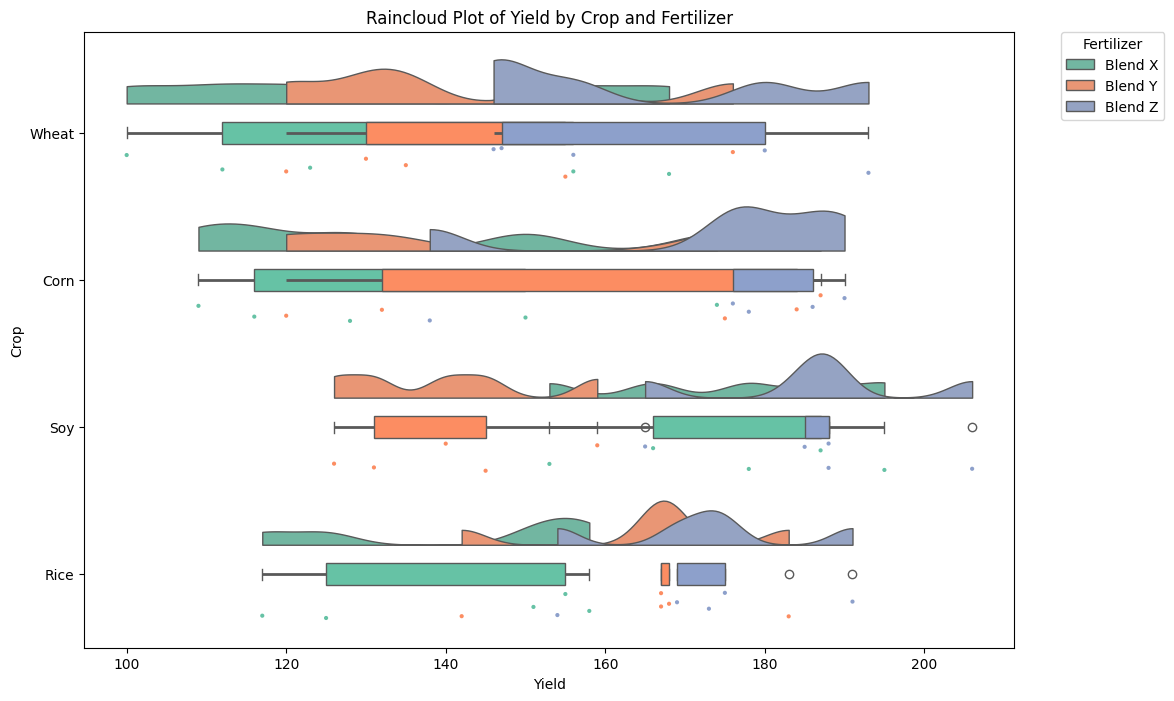

--- Descriptive Statistics filtered by Blend X ---
Crop                        Corn     Rice      Soy    Wheat
Valid                      5.000    5.000    5.000    5.000
Mean                     135.400  141.200  175.800  131.800
Std. Deviation            26.605   18.820   16.694   29.055
Skewness                   0.764   -0.632   -0.385    0.357
Std. Error of Skewness     1.095    1.095    1.095    1.095
Kurtosis                  -0.775   -2.650   -1.062   -2.313
Std. Error of Kurtosis     2.191    2.191    2.191    2.191
Shapiro-Wilk               0.933    0.840    0.976    0.923
P-value of Shapiro-Wilk    0.620    0.164    0.911    0.547


--- Descriptive Statistics filtered by Blend Y ---
Crop                        Corn     Rice      Soy    Wheat
Valid                      5.000    5.000    5.000    5.000
Mean                     159.600  165.400  140.200  143.200
Std. Deviation            31.278   14.741   12.872   22.332
Skewness                  -0.604   -0.954    0.608    0.

In [2]:
!pip install pingouin statsmodels ptitprince -q

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import ptitprince as pt
from statsmodels.datasets import get_rdataset
import numpy as np
from scipy.stats import skew, kurtosis, shapiro, levene

#Dataset from table
data = {
    'Fertilizer': (['Blend X'] * 20) + (['Blend Y'] * 20) + (['Blend Z'] * 20),
    'Crop': (['Wheat']*5 + ['Corn']*5 + ['Soy']*5 + ['Rice']*5) * 3,
    'Yield': [
        #Blend X
        123, 156, 112, 100, 168, 128, 150, 174, 116, 109, 166, 178, 187, 153, 195, 151, 125, 117, 155, 158,
        #Blend Y
        135, 130, 176, 120, 155, 175, 132, 120, 187, 184, 140, 145, 159, 131, 126, 167, 183, 142, 167, 168,
        #Blend Z
        156, 180, 147, 146, 193, 186, 138, 178, 176, 190, 185, 206, 188, 165, 188, 175, 173, 154, 191, 169
    ]
}
df = pd.DataFrame(data)

#Raincloud Plot
plt.figure(figsize=(12, 8))

ax = pt.RainCloud(x='Crop', y='Yield', hue='Fertilizer', data=df,
                  palette='Set2', bw=0.2, width_viol=0.6,
                  orient='h', move=0.2)

plt.title('Raincloud Plot of Yield by Crop and Fertilizer')
plt.show()


# define the table function
def get_detailed_stats(data):
    stats = {}
    stats['Valid'] = len(data)
    stats['Mean'] = np.mean(data)
    stats['Std. Deviation'] = np.std(data, ddof=1)
    stats['Skewness'] = skew(data, bias=False)
    stats['Std. Error of Skewness'] = np.sqrt(6 / len(data))
    stats['Kurtosis'] = kurtosis(data, bias=False)
    stats['Std. Error of Kurtosis'] = np.sqrt(24 / len(data))

    # Shapiro-Wilk Test
    w_stat, p_val = shapiro(data)
    stats['Shapiro-Wilk'] = w_stat
    stats['P-value of Shapiro-Wilk'] = p_val

    return pd.Series(stats)

# Generate tables for all blends
fertilizers = df['Fertilizer'].unique()

for f in fertilizers:
    print(f"--- Descriptive Statistics filtered by {f} ---")
    f_data = df[df['Fertilizer'] == f]
    table = f_data.groupby('Crop')['Yield'].apply(get_detailed_stats).unstack(0)

    print(table.round(3))
    print("\n" + "="*50 + "\n")


#Levene's test and combine the groups
df['Combined'] = df['Fertilizer'] + "_" + df['Crop']
groups = [group['Yield'].values for name, group in df.groupby('Combined')]

stat, p_val = levene(*groups)

df1 = len(groups) - 1
df2 = len(df) - len(groups)

#Create Table
levene_table = pd.DataFrame({
    'Levene Statistic': [stat],
    'df1': [df1],
    'df2': [df2],
    'Sig.': [p_val]
})

print("--- Test of Homogeneity of Variances ---")
print(levene_table.round(3).to_string(index=False))
print("\n" + "="*50 + "\n")

# Computation: Two-Way ANOVA
anova_results = pg.anova(data=df, dv='Yield', between=['Fertilizer', 'Crop'], detailed=True)

def get_col(options, df_cols):
    for opt in options:
        if opt in df_cols: return opt
    return None

p_col = get_col(['p_unc', 'p-unc', 'p-val', 'p'], anova_results.columns)
np2_col = get_col(['np2', 'partial_eta_sq'], anova_results.columns)

anova_table = anova_results[['Source', 'SS', 'DF', 'MS', 'F', p_col, np2_col]].copy()
anova_table.columns = ['Source', 'Type III Sum of Squares', 'df', 'Mean Square', 'F', 'Sig.', 'Partial Eta Squared']

print("--- ANOVA - Tests of Between-Subjects Effects ---")
print(anova_table.round(4).to_string(index=False))
print("\n")
print("\n" + "="*50 + "\n")

print("--- Simple Main Effects of Fertilizer within Crop ---")
for crop in df['Crop'].unique():
    sub_df = df[df['Crop'] == crop]
    res = pg.anova(data=sub_df, dv='Yield', between='Fertilizer')
    p_col_for_res = get_col(['p_unc', 'p-unc', 'p-val', 'p'], res.columns)
    print(f"\nANOVA for {crop}:")
    print(res[['Source', 'F', p_col_for_res]].round(4))

print("\n--- Simple Main Effects of Crop within Fertilizer ---")
for fert in df['Fertilizer'].unique():
    sub_df = df[df['Fertilizer'] == fert]
    res = pg.anova(data=df[df['Fertilizer'] == fert], dv='Yield', between='Crop')
    p_col_for_res_fert = get_col(['p_unc', 'p-unc', 'p-val', 'p'], res.columns)
    print(f"\nANOVA for {fert}:")
    print(res[['Source', 'F', p_col_for_res]].round(4))

print("\n" + "="*50 + "\n")

#post-hoc analysis for crops
for crop in df['Crop'].unique():
    print(f"\n--- Post-Hoc: Fertilizer Comparisons for {crop} ---")
    sub_df = df[df['Crop'] == crop]

    ph = pg.pairwise_tukey(data=sub_df, dv='Yield', between='Fertilizer')

    print(ph[['A', 'B', 'diff', 'se', 'T', 'p_tukey']].round(4))

all_desc = df.groupby(['Crop', 'Fertilizer'])['Yield'].agg(['mean', 'std']).round(2)
print("\n--- Descriptives ---")
print(all_desc)